In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from segmentflow import segment, view
import skimage as ski

In [2]:
user = (
    'cgusb' if 'cgusb' in [f.stem for f in Path(r"C:\Users").iterdir()]
    else 'gusb'
)
img_dir = Path(
    # fr'C:\Users\{user}\Research\mhe-analysis\results'
    # fr'\prill_1_0.25-scale_segmented\prill_1_0.25-scale_labeled_voxels'
    fr'C:\Users\{user}\Research\mhe-analysis\data'
    fr'\IDOX_prill_1\prill_1_0.25-scale'
)
imgs = segment.load_images(img_dir, file_suffix='.tiff')

Loading images...
--> Images loaded as 3D array:  (498, 508, 496)


In [16]:
factor = 2
nslices, nrows, ncols = imgs.shape
# vol_nslices, vol_nrows, vol_ncols = np.array([nslices, nrows, ncols])//factor
ellip_ncols = ncols/factor//2
ellip_nrows = nrows/factor//2
ellip_nslices = nslices/factor//2
ellip = ski.draw.ellipsoid(ellip_ncols, ellip_nrows, ellip_nslices)
print(f'{ellip.shape=}')
slice_offset = np.random.randint(0, nslices)
row_offset = np.random.randint(0, nrows)
col_offset = np.random.randint(0, ncols)
offsets = {}
offsets[0] = slice_offset
offsets[1] = row_offset
offsets[2] = col_offset
print(f'{offsets=}')
sorted_offsets = [v for k, v in sorted(offsets.items())]
print(f'{sorted_offsets=}')

ellip.shape=(251, 257, 251)
offsets={0: 265, 1: 285, 2: 223}
sorted_offsets=[265, 285, 223]


--> Plotting images: [  0  62 125 187 250]


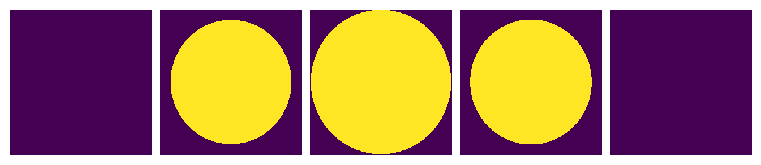

In [4]:
fig, ax = view.vol_slices(ellip, nslices=5)

In [17]:
mask = np.zeros_like(imgs)
print(f'{mask.shape=}')
print(f'{sorted_offsets=}')
print(f'{ellip.shape=}')
mask_upper_bounds = {}
for i in range(3):
    mask_upper_bounds[i] = offsets[i] + ellip.shape[i]
    if mask_upper_bounds[i] > mask.shape[i]:
        mask_upper_bounds[i] = mask.shape[i]
mask_nonzero_shape = mask[
    offsets[0]:mask_upper_bounds[0],
    offsets[1]:mask_upper_bounds[1],
    offsets[2]:mask_upper_bounds[2]
].shape
print(f'{mask_nonzero_shape=}')

mask.shape=(498, 508, 496)
sorted_offsets=[265, 285, 223]
ellip.shape=(251, 257, 251)
mask_nonzero_shape=(233, 223, 251)


--> Plotting images: [  0 124 248 372 497]


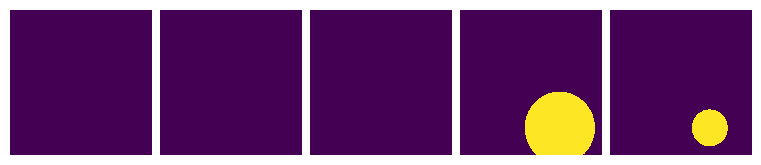

In [20]:
mask[
    offsets[0]:mask_upper_bounds[0],
    offsets[1]:mask_upper_bounds[1],
    offsets[2]:mask_upper_bounds[2]
] = ellip[
    :mask_upper_bounds[0]-offsets[0],
    :mask_upper_bounds[1]-offsets[1],
    :mask_upper_bounds[2]-offsets[2]
]
fig, ax = view.vol_slices(mask, nslices=5)

--> Plotting images: [  0 124 248 372 497]
--> Plotting images: [  0 124 248 372 497]
--> Plotting images: [  0 124 248 372 497]
--> Plotting images: [  0 124 248 372 497]
--> Plotting images: [  0 124 248 372 497]
--> Plotting images: [  0 124 248 372 497]
--> Plotting images: [  0 124 248 372 497]
--> Plotting images: [  0 124 248 372 497]
--> Plotting images: [  0 124 248 372 497]
--> Plotting images: [  0 124 248 372 497]


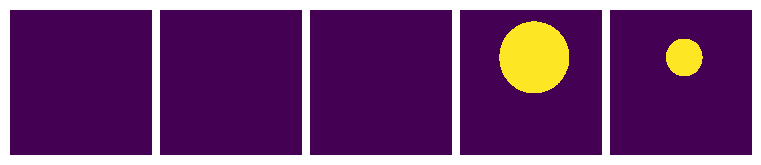

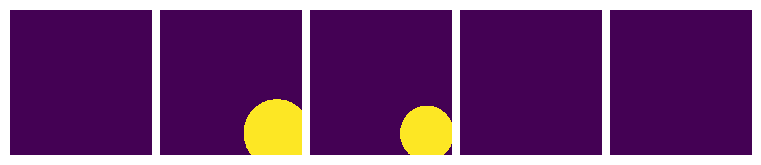

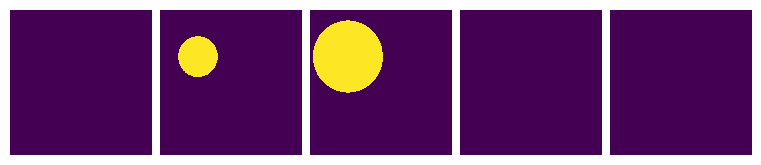

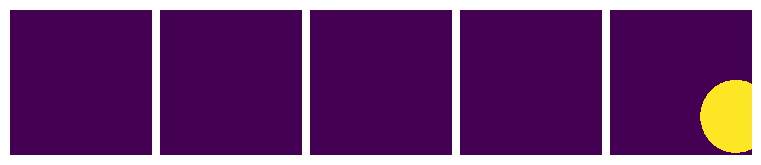

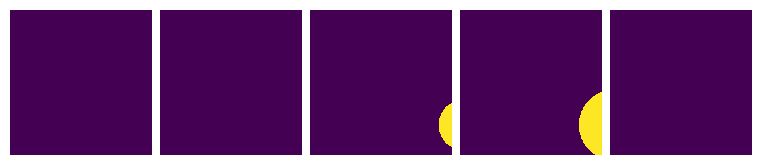

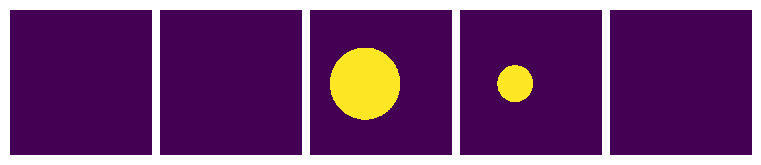

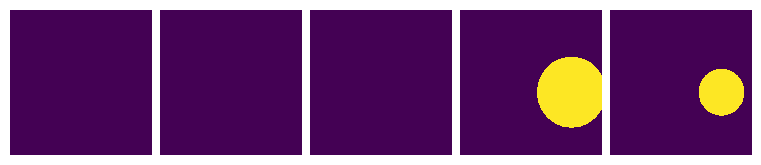

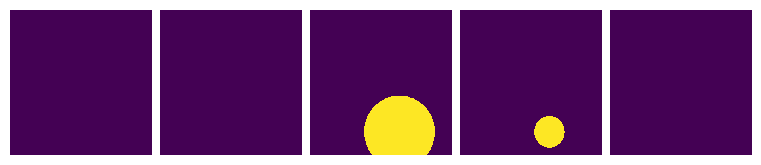

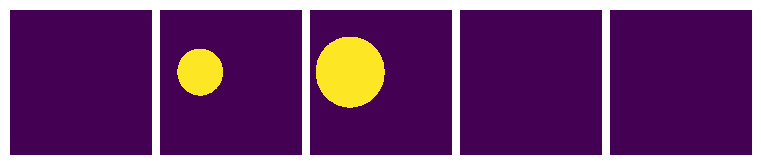

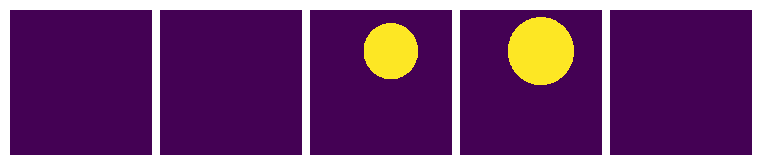

In [30]:
def get_spherical_masks(imgs, factor=2, loc_range_frac=(0, 1)):
    nslices, nrows, ncols = imgs.shape
    ellip_ncols = ncols/factor//2
    ellip_nrows = nrows/factor//2
    ellip_nslices = nslices/factor//2
    ellip = ski.draw.ellipsoid(ellip_ncols, ellip_nrows, ellip_nslices)
    offsets = {}
    for i in range(3):
        # offsets[i] = np.random.randint(0, imgs.shape[i])
        offsets[i] = np.random.randint(
            loc_range_frac[0]*imgs.shape[i],
            loc_range_frac[1]*imgs.shape[i])
    mask = np.zeros_like(imgs)
    mask_upper_bounds = {}
    for i in range(3):
        mask_upper_bounds[i] = offsets[i] + ellip.shape[i]
        if mask_upper_bounds[i] > mask.shape[i]:
            mask_upper_bounds[i] = mask.shape[i]
    mask[
        offsets[0]:mask_upper_bounds[0],
        offsets[1]:mask_upper_bounds[1],
        offsets[2]:mask_upper_bounds[2]
] = ellip[
    :mask_upper_bounds[0]-offsets[0],
    :mask_upper_bounds[1]-offsets[1],
    :mask_upper_bounds[2]-offsets[2]
]
    return mask

for i in range(5):
    mask = get_spherical_masks(imgs, loc_range_frac=(0, 1))
    fig, axes = view.vol_slices(mask, nslices=5)
for i in range(5):
    mask = get_spherical_masks(imgs, loc_range_frac=(0, 3/4))
    fig, axes = view.vol_slices(mask, nslices=5)